# Try PathFinder on Retinotopy data

Use task (retinotopy) data with different stimuli to jointly model brain response and stimuli, and use PathFinder principle to predict stimulus.


In [1]:
from pathfinder import utils, decomp
# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---

<module 'pathfinder.decomp' from '/opt/miniconda3/envs/py38/lib/python3.8/site-packages/pathfinder/decomp.py'>

In [2]:
# Load stimuli
import numpy as np
npzfile = np.load('../pathfinder/data/retino.npz')

stims_names = sorted(npzfile.files)
stims       = [  npzfile[name] for name in stims_names ]

In [3]:
# Visualise stimuli
# HELPER FUNCTION
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def animate(X):
    """ X is a 3D array with time as first dimension
    """
    T = X.shape[0]    
    fig, ax = plt.subplots()
    plt.close()

    ims = []
    for i in range(T):    
        im = ax.imshow(X[i], animated=True)
        ims.append([im])

    ani = animation.ArtistAnimation(fig, ims, interval=20, blit=True, repeat_delay=1000)

    return HTML(ani.to_html5_video())


In [4]:
# Look at stimuli

animate(stims[0])


In [5]:
# Generate Retinotopy data using PRF modelling

from numba import njit, prange

# HRF Convolution
from scipy.stats import gamma
from scipy.signal import fftconvolve
def hrf(times):
    # Gamma pdf for the peak
    peak_values = gamma.pdf(times, 6)
    # Gamma pdf for the undershoot
    undershoot_values = gamma.pdf(times, 12)
    # Combine 
    values = peak_values - 0.35 * undershoot_values
    # Scale 
    return values / np.max(values) * 0.6

def hrf_convolve(x, TR=1.):
    tr_times    = np.arange(0, len(x), TR)
    hrf_at_trs  = hrf(tr_times)
    n_to_remove = len(hrf_at_trs) - 1    
    return fftconvolve(x, hrf_at_trs[:,None, None], axes=0)[:-n_to_remove,...]

# PRF Model

# Parallelise stim X retino
@njit(parallel=True)
def calc_sG(s, x, y, x0, y0, sig):
    """ calculate s*G(xy, xy0) by parallelizing over xy0
    """
    s = np.reshape(s, (s.shape[0],-1) )
    x, y, x0, y0 = x.flatten(), y.flatten(), x0.flatten(), y0.flatten()
    ret = np.zeros((s.shape[0], len(x0)))
    for i in prange(len(x0)):
        w_i = np.exp(-((x-x0[i])**2 + (y-y0[i])**2)/2./sig**2)
        ret[:,i] = s @ w_i / np.sum(w_i)
    return ret
    
# PRF Mode
def prf( stim, x0, y0, sig, TR=1., bold=False ):
    """stim->neural activity->bold
    stim      : 3D array of size T-times-(N_x-times-N_y)
    x0,y0,sig : 1D array of receptive fields
    """
    nx, ny = stim.shape[1:]
    x,  y  = np.linspace(-1, 1, nx), np.linspace(-1, 1, ny)
    xv, yv = np.meshgrid(x, y, indexing='ij')
    
    # G is (NxNy)x(N) - too big?
    # G = np.exp(-(np.subtract.outer(xv, x0.flatten())**2 + np.subtract.outer(yv, y0.flatten())**2)/sig**2/2.)        
    sG = calc_sG(stim, xv, yv, x0, y0, sig)
    sG = np.reshape(sG, (sG.shape[0],x0.shape[0],x0.shape[1]))
    
    if bold:
        sG = hrf_convolve(sG, TR=TR)
        
    return sG


In [6]:
# 2D model of V1 (as a square)
V1_x0, V1_y0 = np.meshgrid( np.linspace(-1, 1, 50), np.linspace(-1, 1, 50) , indexing='ij')
sig          = .1

# Convolve the stimulus
stims_hrf = [ hrf_convolve(s) for s in stims]

from tqdm import tqdm
Brain_data = []
for s in tqdm(stims_hrf):
    r = prf( s, V1_x0, V1_y0, sig, TR=1., bold=False )
    Brain_data.append(r)


100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.06s/it]


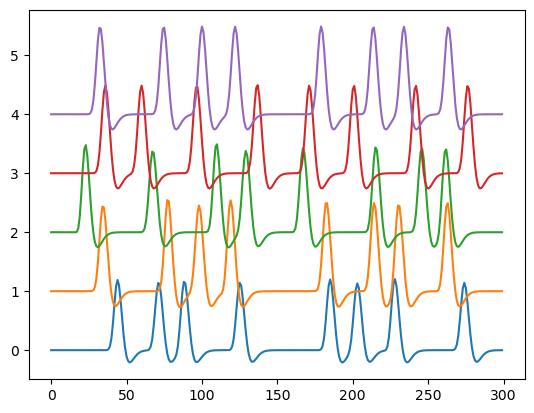

In [7]:
# Look at the data
stim_id = 0
data    = Brain_data[stim_id]

import matplotlib.pyplot as plt
idx = [np.random.randint(50*50) for i in range(5)]
for i, j in enumerate(idx):    
    x = data.reshape((300,-1))[:,j]
    plt.plot(i+x)    
plt.show()


In [10]:
# Look at response
stim_id = 2
data    = Brain_data[stim_id]

animate(data)


In [11]:
# Organise for PathFinder

PRF_Data          = { 'Stim' : {}, 'Brain' : {} }
PRF_Data_complete = { 'Stim' : {}, 'Brain' : {} }

for i, c in enumerate(stims_names):
    PRF_Data_complete['Stim'][c]  = stims_hrf[i].reshape((300,-1)).T
    PRF_Data_complete['Brain'][c] = Brain_data[i].reshape((300,-1)).T
    
    PRF_Data['Stim'][c]  = stims_hrf[i].reshape((300,-1)).T
    PRF_Data['Brain'][c] = Brain_data[i].reshape((300,-1)).T

PRF_Data['Stim']['RETCCW'] = None


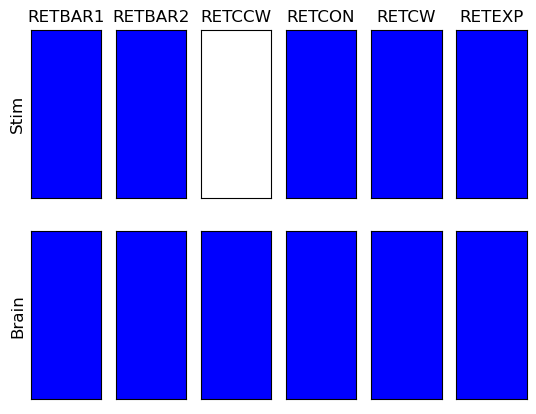

In [12]:
_ = utils.plot_data_grid(PRF_Data)

In [14]:
from pathfinder import decomp

from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=10, n_iter=10, dropout=-1, 
                               method=Ridge, method_kwargs={'alpha':1e2})
algo.fit(PRF_Data)


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:25<00:00,  2.60s/it]


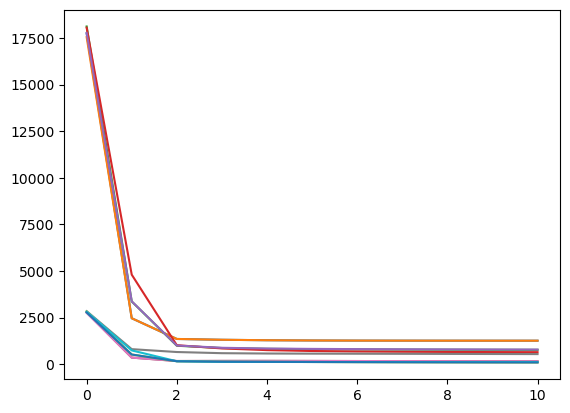

In [16]:
# Look at error / convergence
import matplotlib.pyplot as plt

_ = plt.plot(algo._loss)

In [17]:

PRF_Data_Pred = utils.predicted_data_grid(PRF_Data, algo._A, algo._S)

name = 'RETCCW'
nx, ny = stims[stims_names.index(name)].shape[1:]
X = PRF_Data_Pred['Stim'][name]
x = np.reshape(X.T, (-1, nx, ny ) )
animate(x)


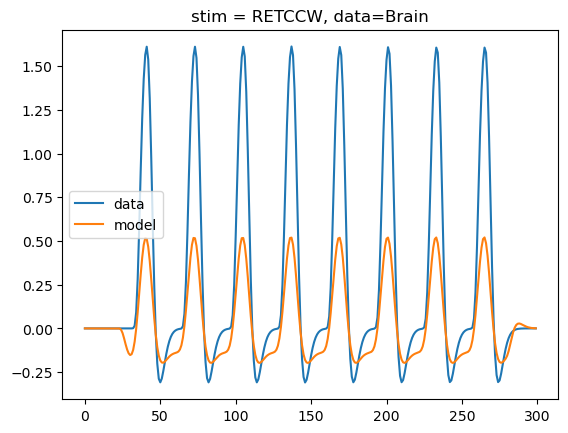

In [18]:
# Look at predictions

name  = 'RETCCW'
which = 'Brain'   # 'Brain' or 'Stim'

if which == 'Stim':
    nx, ny = stims[stims_names.index(name)].shape[1:]
else:
    nx, ny = Brain_data[stims_names.index(name)].shape[1:]

# pick a random pixel
i, j = np.random.randint(0, nx), np.random.randint(0, ny)

X      = PRF_Data_complete[which][name].T.reshape((300,nx,ny))
X_pred = PRF_Data_Pred[which][name].T.reshape((300,nx,ny))

plt.figure()
plt.plot(X[:,i,j], label ='data')
plt.plot(X_pred[:,i,j], label='model')
plt.legend()
plt.title(f'stim = {name}, data={which}')
plt.show()


## Now let's have a go at real retinotopy data

Data is from HCP 7T - averaged across 100+ subjects.

In [19]:
# visual cortex mask
import nibabel as nib
# change below once file is moved
parcel_cifti = nib.load('/Users/saad/data/GlasserParcellation.dlabel.nii')
table        = parcel_cifti.header.matrix._mims[0]._maps[0]._label_table
labels       = [table[i].label.replace('_ROI','') for i in range(len(table))]


# --> 91k
idx       = parcel_cifti.header.matrix._mims[1]._maps[0]._vertex_indices
offset    = parcel_cifti.header.matrix._mims[1]._maps[0].index_offset
left_idx  = [idx[i]+offset for i in range(len(idx))]
idx       = parcel_cifti.header.matrix._mims[1]._maps[1]._vertex_indices
offset    = parcel_cifti.header.matrix._mims[1]._maps[1].index_offset
right_idx = [idx[i]+offset for i in range(len(idx))]
both_idx  = left_idx+right_idx
parc_91k  = np.zeros(91282)
parc_91k[both_idx] = parcel_cifti.get_fdata()


# ROI contains V1 for both hemispheres
ROI = ['R_V1', 'L_V1']
# ROI = ['R_V1']

mask_V1 = np.isin(parc_91k, [labels.index(r) for r in ROI])



pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [20]:
# Get the data
from glob import glob
import os

data_folder = '/Users/saad/Documents/Teaching/NMA/HCP7T_retino'
data_files  = [ glob(os.path.join(data_folder,f'tfMRI_{c}_7T_??.dtseries.nii'))[0] for c in stims_names ]
data_cifti  = [ nib.load(f) for f in data_files ]


In [21]:
# Rescale data
def rescale(x, m=.05, M=.95):
    return (x - np.quantile(x,m,axis=0)) / (np.quantile(x,M,axis=0) - np.quantile(x,m,axis=0))
    
Retino_Data_matrices = [rescale(d.get_fdata())[:, mask_V1] for d in data_cifti]


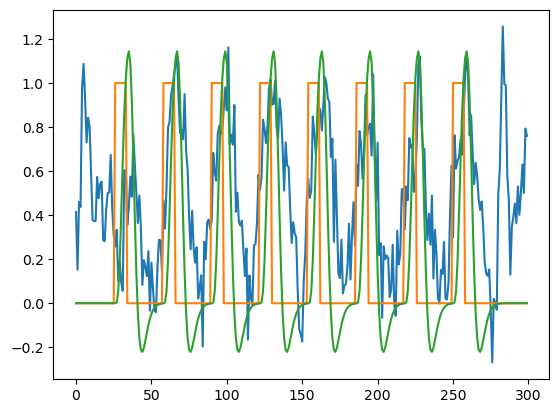

In [22]:
# Have a quick look
plt.plot(Retino_Data_matrices[2][:,100])
plt.plot(stims[2][:,50,50])
plt.plot(stims_hrf[2][:,50,50]/2.5)


In [23]:
# Prepare the data for PathFinder

Retino_Data_complete = { 'Stim' : {}, 'Brain' : {} }
Retino_Data          = { 'Stim' : {}, 'Brain' : {} }

for i,c in enumerate(stims_names):
    Retino_Data_complete['Stim'][c]  = stims_hrf[i].reshape((300,-1)).T
    Retino_Data_complete['Brain'][c] = Retino_Data_matrices[i].reshape((300,-1)).T
    
    Retino_Data['Stim'][c]  = stims_hrf[i].reshape((300,-1)).T
    Retino_Data['Brain'][c] = Retino_Data_matrices[i].reshape((300,-1)).T

Retino_Data['Stim']['RETCCW'] = None


In [24]:
# Run PathFinder

from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=10, n_iter=10, dropout=-1, 
                               method=Ridge, method_kwargs={'alpha':1e2})
algo.fit(Retino_Data)


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:32<00:00,  3.30s/it]


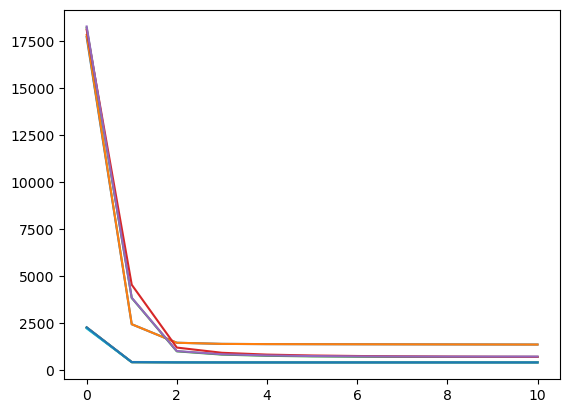

In [25]:
# Look at error / convergence
import matplotlib.pyplot as plt
_ = plt.plot(algo._loss)

In [27]:
# Look at predicted stimulus
Retino_Data_Pred = utils.predicted_data_grid(Retino_Data, algo._A, algo._S)

name = 'RETCCW'
nx, ny = stims[stims_names.index(name)].shape[1:]
X = Retino_Data_Pred['Stim'][name]
x = np.reshape(X.T, (-1, nx, ny ) )
animate(x)


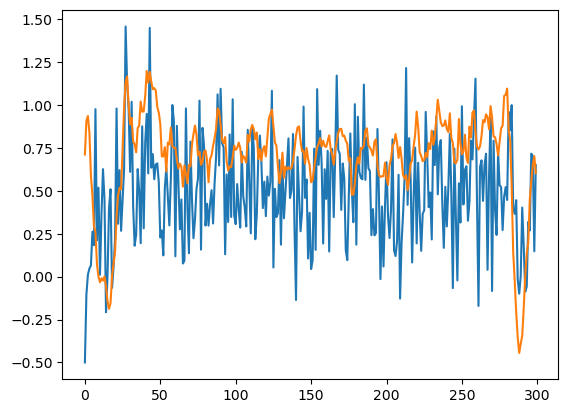

In [28]:
# Have a look at brain data fit

name = 'RETCCW'
idx  = stims_names.index(name)

data = Retino_Data_matrices[idx][:,300]
pred = Retino_Data_Pred['Brain'][name][300,:]

plt.plot(rescale(data))
plt.plot(rescale(pred))


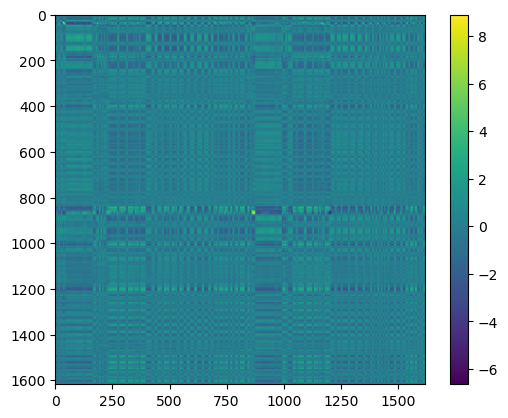

In [29]:
# Correlation between model and data
name = 'RETBAR1'
idx  = stims_names.index(name)

data = Retino_Data_matrices[idx]
pred = Retino_Data_Pred['Brain'][name].T

def normalise(x, axis=0):
    m = np.mean(x,axis=axis,keepdims=True)
    s = np.std(x,axis=axis,keepdims=True)
    return (x-m)/s/np.sqrt(x.shape[axis])
    
def row_col_normalise(x):
    T, N = x.shape 
    x = x / (np.ones((T,1))*np.std(x, axis=0, keepdims=True))
    normx = x - np.outer(np.mean(x, axis=1),np.ones(N))- np.outer(np.ones(T),np.mean(x, axis=0)) + np.mean(np.mean(x,axis=0))
    return normx

C = normalise(data).T@normalise(pred)


plt.figure()
plt.imshow(row_col_normalise(C))
plt.colorbar()
plt.show()